In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
print("Libraries loaded!")

Libraries loaded!


In [10]:
df = pd.read_csv('/matches.csv')
print("Shape:", df.shape)
df.head()

Shape: (1095, 20)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


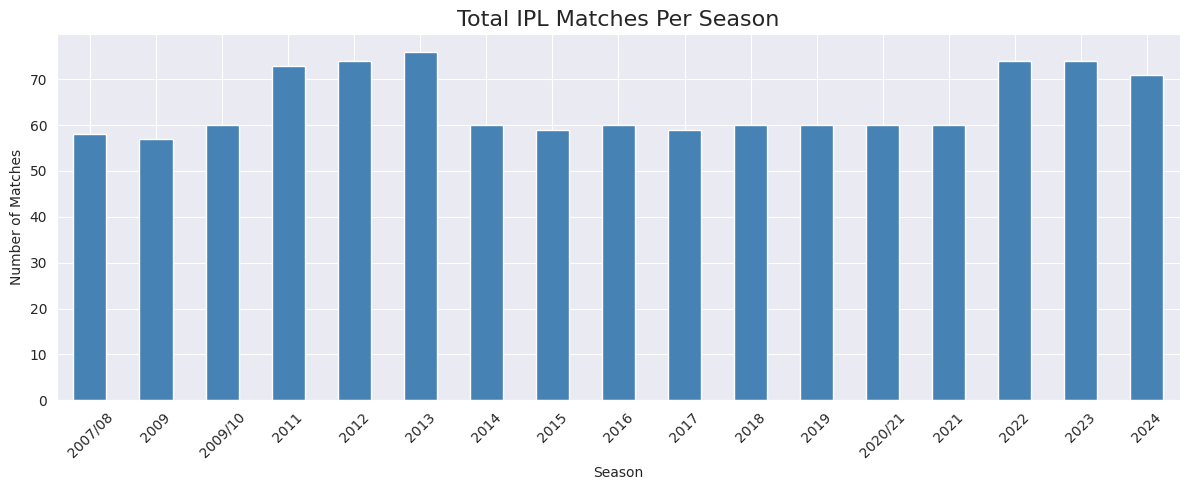

In [11]:
# Total matches per season
matches_per_season = df.groupby('season')['id'].count()

plt.figure(figsize=(12,5))
matches_per_season.plot(kind='bar', color='steelblue')
plt.title('Total IPL Matches Per Season', fontsize=16)
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('matches_per_season.png')
plt.show()

/tmp/ipykernel_5109/1430311552.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_teams.values, y=top_teams.index, palette='viridis')


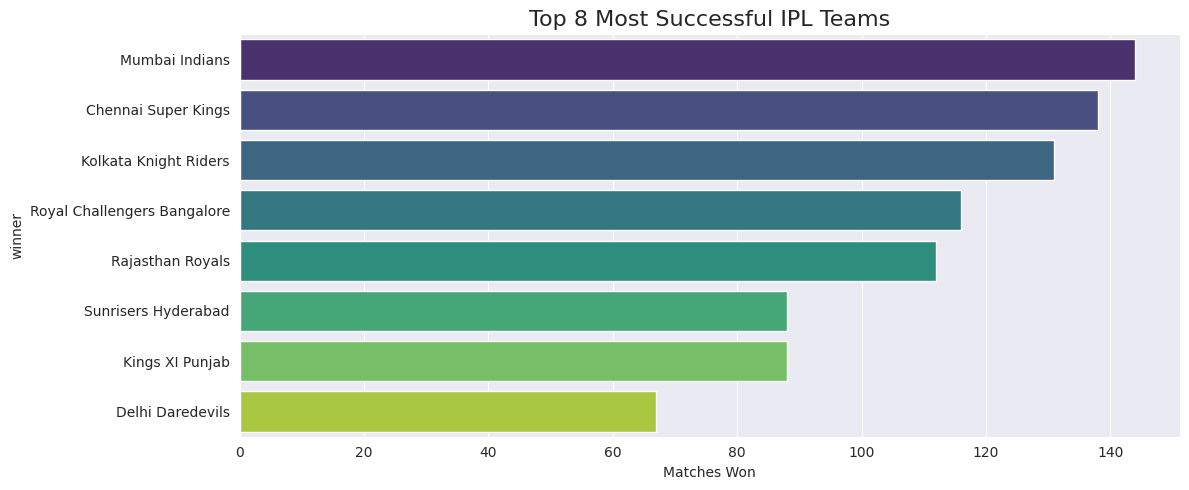

In [12]:
# Most matches won
top_teams = df['winner'].value_counts().head(8)

plt.figure(figsize=(12,5))
sns.barplot(x=top_teams.values, y=top_teams.index, palette='viridis')
plt.title('Top 8 Most Successful IPL Teams', fontsize=16)
plt.xlabel('Matches Won')
plt.tight_layout()
plt.savefig('top_teams.png')
plt.show()

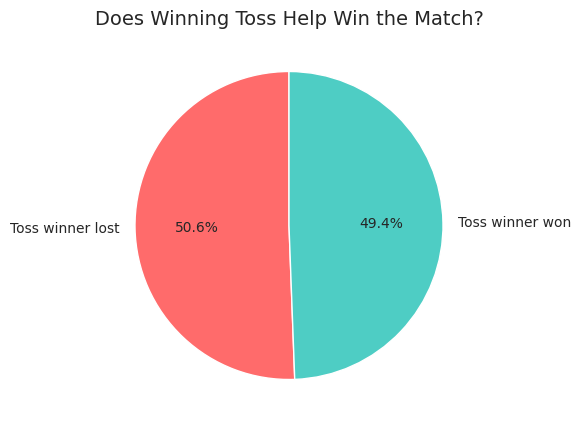

In [13]:
# Toss winner = match winner?
df['toss_match_win'] = df['toss_winner'] == df['winner']
toss_impact = df['toss_match_win'].value_counts()

plt.figure(figsize=(7,5))
plt.pie(toss_impact, labels=['Toss winner lost', 'Toss winner won'],
        autopct='%1.1f%%', colors=['#ff6b6b','#4ecdc4'], startangle=90)
plt.title('Does Winning Toss Help Win the Match?', fontsize=14)
plt.savefig('toss_impact.png')
plt.show()

/tmp/ipykernel_5109/1052769050.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_venues.values, y=top_venues.index, palette='magma')


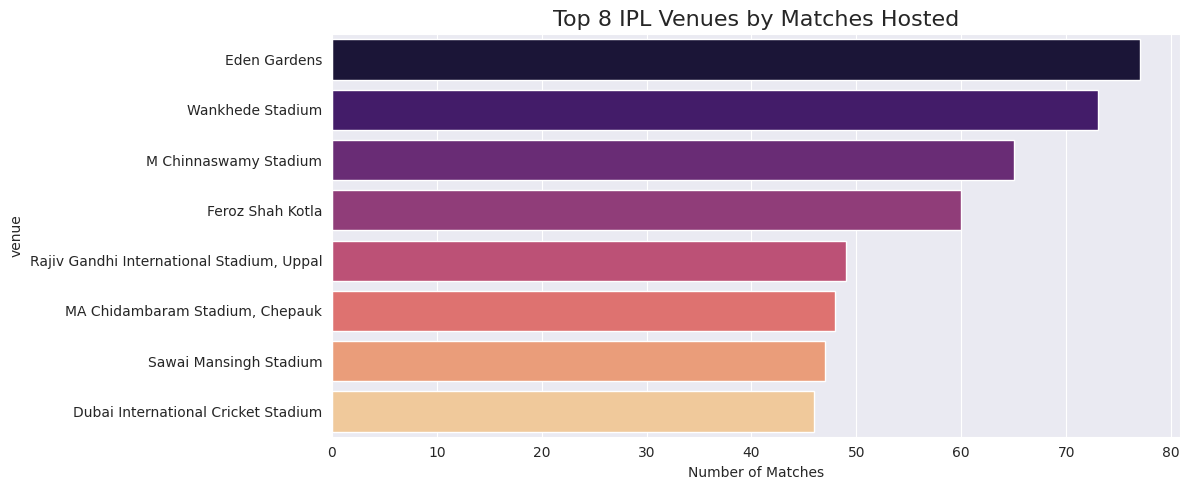

In [14]:
# Top match venues
top_venues = df['venue'].value_counts().head(8)

plt.figure(figsize=(12,5))
sns.barplot(x=top_venues.values, y=top_venues.index, palette='magma')
plt.title('Top 8 IPL Venues by Matches Hosted', fontsize=16)
plt.xlabel('Number of Matches')
plt.tight_layout()
plt.savefig('top_venues.png')
plt.show()

In [15]:
print("=== IPL ANALYSIS SUMMARY ===")
print(f"Total Matches Analysed: {len(df)}")
print(f"Total Seasons: {df['season'].nunique()}")
print(f"Total Teams: {df['team1'].nunique()}")
print(f"Total Venues: {df['venue'].nunique()}")
print(f"Most Successful Team: {df['winner'].value_counts().index[0]}")
print(f"Most Used Venue: {df['venue'].value_counts().index[0]}")

=== IPL ANALYSIS SUMMARY ===
Total Matches Analysed: 1095
Total Seasons: 17
Total Teams: 19
Total Venues: 58
Most Successful Team: Mumbai Indians
Most Used Venue: Eden Gardens
